In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# output directory for plots
os.makedirs('../plots', exist_ok=True)
output_dir = '../plots/'

# Read results
df = pd.read_csv('../data/runs.csv')

avg_df = df[df['trial'] == 'Average'].copy()

# Speedup
T1 = avg_df['seconds'].iloc[0]
avg_df['Speedup'] = T1 / avg_df['seconds']

# Efficiency
avg_df['Efficiency'] = avg_df['Speedup'] / avg_df['nodes']

# Karp-Flatt
avg_df['Karp_Flatt'] = ((1 / avg_df['Speedup']) - (1 / avg_df['nodes'])) / (1 - (1 / avg_df['nodes']))

avg_df

,N,p,nodes,ppn,trial,seconds,Speedup,Efficiency,Karp_Flatt
10,499999999,1,1,1,Average,8.913060,1.000000,1.000000,NaN
21,499999999,2,2,1,Average,4.456550,1.999991,0.999996,0.000004
32,499999999,3,3,1,Average,2.971040,2.999980,0.999993,0.000003
43,499999999,4,4,1,Average,2.228410,3.999740,0.999935,0.000022
54,499999999,5,5,1,Average,1.782640,4.999921,0.999984,0.000004
65,499999999,6,6,1,Average,1.485660,5.999394,0.999899,0.000020
76,499999999,7,7,1,Average,1.273900,6.996672,0.999525,0.000079
87,499999999,8,8,1,Average,1.114360,7.998367,0.999796,0.000029
98,499999999,9,9,1,Average,0.994559,8.961821,0.995758,0.000533
109,499999999,10,10,1,Average,0.891540,9.997375,0.999738,0.000029


Plots saved in 'plots/' directory.


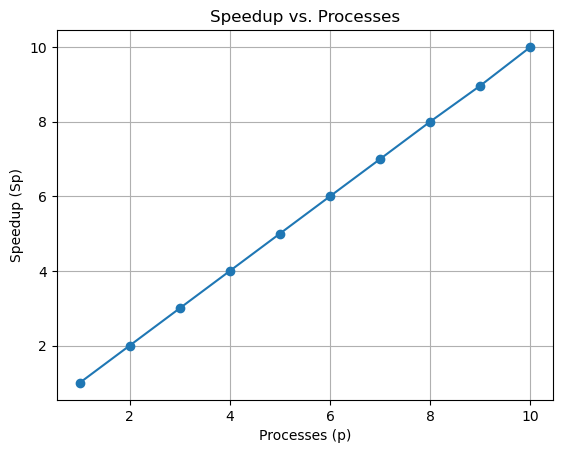

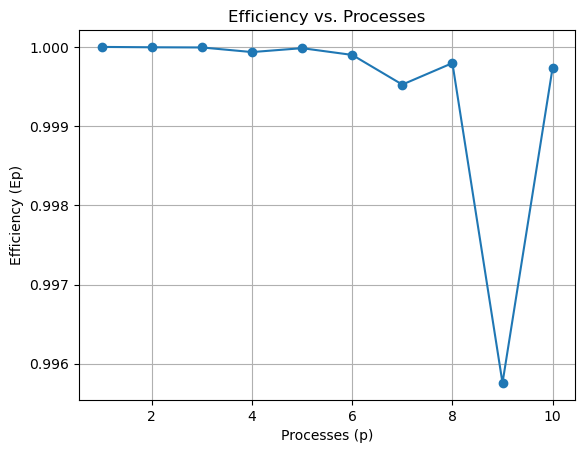

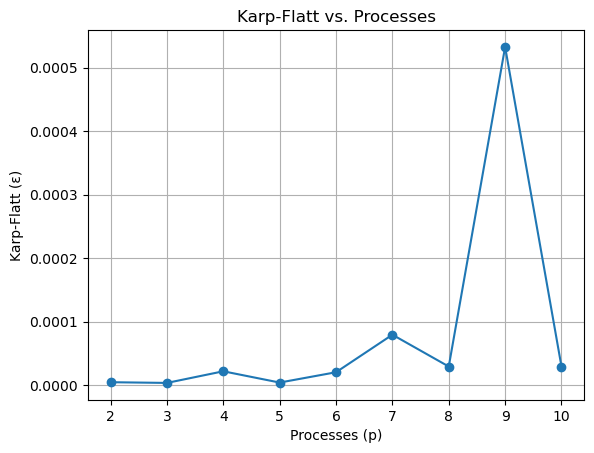

In [2]:

# Speedup plot
plt.figure()
plt.plot(avg_df['nodes'].to_numpy(), avg_df['Speedup'].to_numpy(), marker='o')
plt.xlabel('Processes (p)')
plt.ylabel('Speedup (Sp)')
plt.title('Speedup vs. Processes')
plt.grid(True)
plt.savefig(f'{output_dir}speedup.png')

# Efficiency plot
plt.figure()
plt.plot(avg_df['nodes'].to_numpy(), avg_df['Efficiency'].to_numpy(), marker='o')
plt.xlabel('Processes (p)')
plt.ylabel('Efficiency (Ep)')
plt.title('Efficiency vs. Processes')
plt.grid(True)
plt.savefig(f'{output_dir}efficiency.png')

# Karp-Flatt plot
plt.figure()
plt.plot(avg_df['nodes'].to_numpy(), avg_df['Karp_Flatt'].to_numpy(), marker='o')
plt.xlabel('Processes (p)')
plt.ylabel('Karp-Flatt (ε)')
plt.title('Karp-Flatt vs. Processes')
plt.grid(True)
plt.savefig(f'{output_dir}karp_flatt.png')

print("Plots saved in 'plots/' directory.")
